m#탐색적 데이터 분석 EDA
- 데이터의 주요특징을 파악하고 가설을 세우기 위한방법
- 데이터 분석 초기 단계에 수행되며 데이터를 시각화하고 통계적으로 요약함.

In [6]:
import pandas as pd   #데이터타루기
import matplotlib.pyplot as plt   #그래프그리기
df = pd.read_csv('../datasets/titanic/train.csv')
df.shape

(891, 12)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# 척도
## 질적 척도
    - 명목척도 : 관찰하는 대상의 속성에 따라 그값을 숫자로 나타냄, 분류할 목적으로 숫자를 ㅡ사용하고
             숫자 자체가 가지고 있는 의미는
    - 서열척도 : 관찰하는 대상의 특성을 측정해서 그 값을 순위로 나타내는 것(1등,2등 ...)
             높낮이는 알수있지만 어느정도 차이인지는 알수없음
## 양적 척도
    - 등간척도 : 관찰하는 대상의 속성을 상대적 크기로 나타냄 순위를 부여할뿐만 아니라
                어느정도 큰지 숫자간의 의미가 있음(온도,날씨)가산이
    - 비율척도 : 절대적 기준이 있는 영점이 존재하고 모든 사칙연산이 가능함(판매량,점수,키...)

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
gender_mean = df.groupby('Sex')['Age'].mean()
gender_mean

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [16]:
# 결측치는 평균값,중앙값, 선행값,후행값, 그룹 평균값 등 다양한 값으로 대체할수있음
df.loc[(df['Sex'] == 'female') & (df['Age'].isnull()), 'Age'] = int(gender_mean.iloc[0])
df.loc[(df['Sex'] == 'male') & (df['Age'].isnull()), 'Age'] = int(gender_mean.iloc[1])
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
df.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [18]:
df['Cabin'] = df['Cabin'].fillna('N') #null 값을 N으로
df = df.dropna() #결측값 포함된 행제거
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [19]:
df['Survived'].value_counts() #0:사망 1:생존


Survived
0    549
1    340
Name: count, dtype: int64

In [20]:
df['Survived_label'] = df['Survived'].replace(0, 'Dead').replace(1,'Survived')
df['Survived_label'].value_counts()

Survived_label
Dead        549
Survived    340
Name: count, dtype: int64

<Axes: xlabel='Survived_label'>

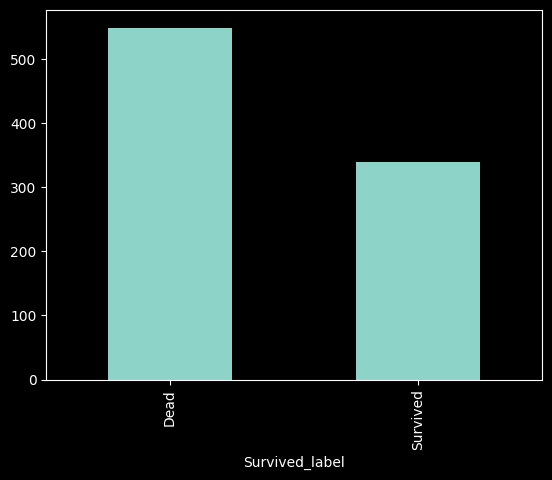

In [21]:
df['Survived_label'].value_counts().plot(kind='bar', rot='vertical')  #바 차트

<Axes: >

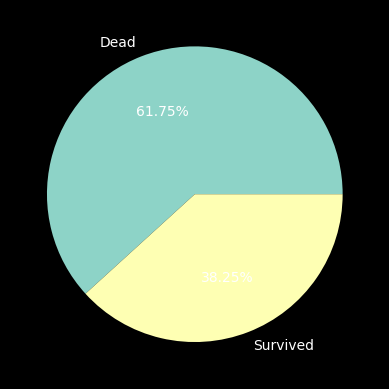

In [22]:
df['Survived_label'].value_counts().plot(kind='pie', autopct='%1.2f%%')

<Axes: >

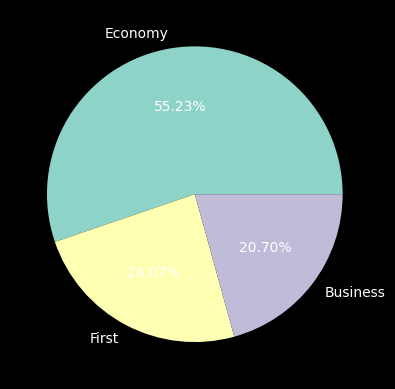

In [23]:
df['Pclass_label'] = df['Pclass'].replace(1, 'First').replace(2,'Business').replace(3, 'Economy')
df['Pclass_label'].value_counts().plot(kind='pie', autopct='%1.2f%%')

<Axes: xlabel='Pclass_label', ylabel='count'>

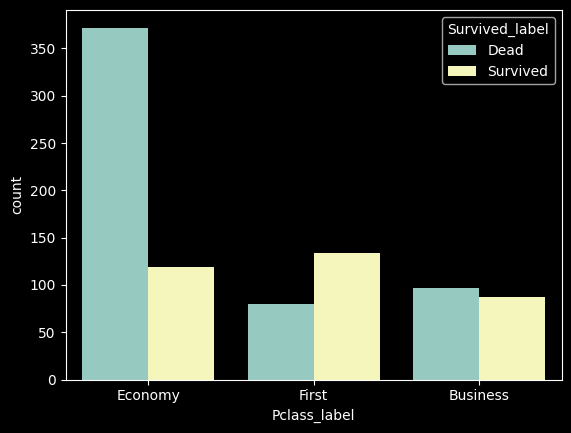

In [27]:
# ipynb에서 설치
!pip install seaborn
import seaborn as sns
sns.countplot(data=df, x='Pclass_label', hue='Survived_label')

<Axes: xlabel='Sex', ylabel='count'>

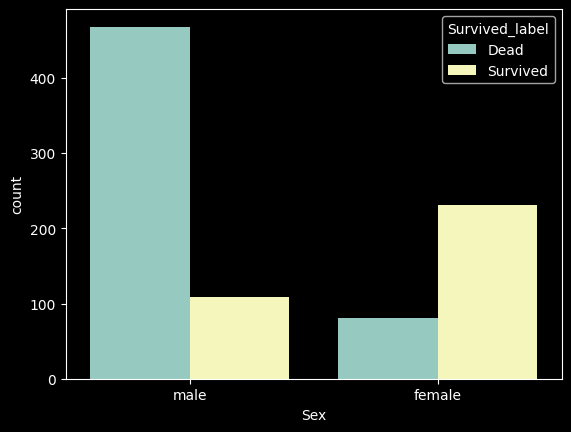

In [28]:
#성별생존
sns.countplot(data=df, x='Sex', hue='Survived_label')

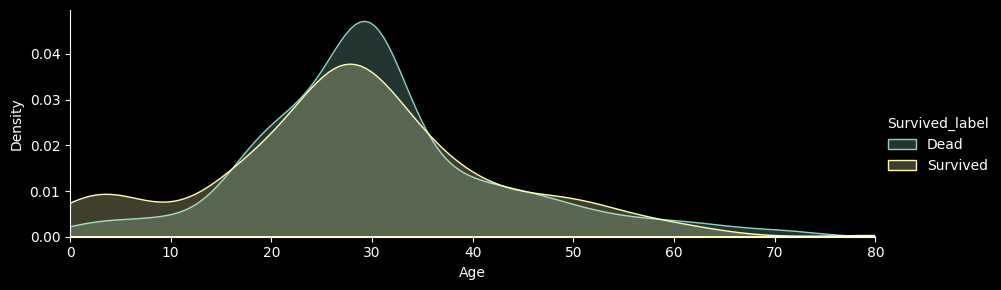

In [29]:
#나이별 생존 여부
f = sns.FacetGrid(df, hue='Survived_label', aspect=3)
f.map(sns.kdeplot, 'Age', fill=True)
f.set(xlim=(0, df['Age'].max()))
f.add_legend()


<Axes: xlabel='SibSp', ylabel='count'>

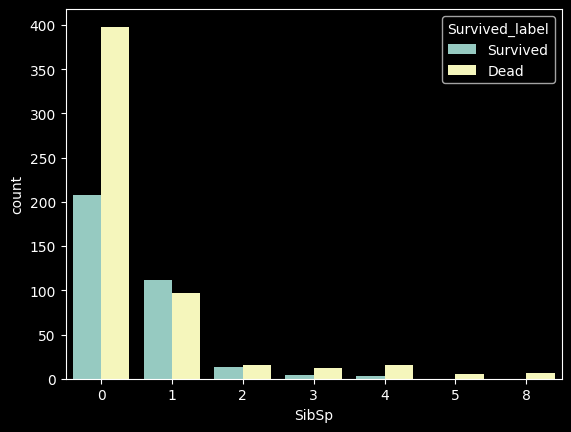

In [30]:
#형제 배우자
sns.countplot(data=df, x='SibSp', hue='Survived_label')

<Axes: xlabel='Parch', ylabel='count'>

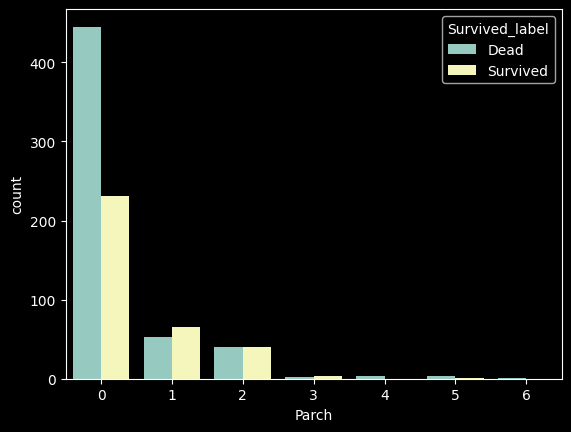

In [31]:
#부모자식
sns.countplot(data=df, x='Parch', hue='Survived_label')


<Axes: xlabel='Single', ylabel='count'>

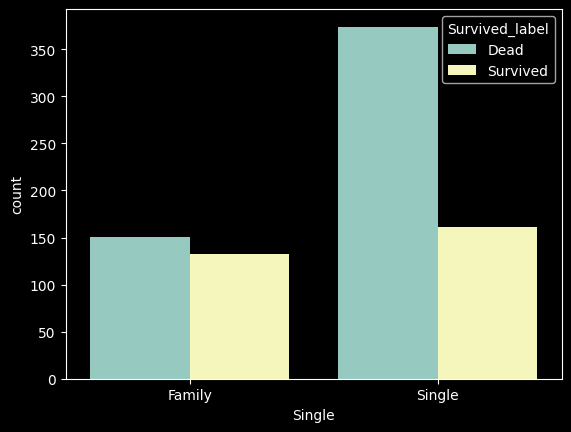

In [34]:
#가족 유무
df.loc[(df['SibSp'] == 0) & (df['Parch'] == 0), 'Single'] = 'Single'
df.loc[(df['SibSp'] != 0) & (df['Parch'] != 0), 'Single'] = 'Family'
sns.countplot(data=df, x='Single', hue='Survived_label')